In [2]:
import os
print(os.listdir("../dataset"))

['extracted', 'processed', 'raw']


In [3]:
print(os.listdir("../dataset/extracted"))


['Dataset Dyslexia_Password WanAsy321']


In [4]:
print(os.listdir("../dataset/extracted"))

['Dataset Dyslexia_Password WanAsy321']


In [5]:
path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321"

print(os.listdir(path))

['Gambo']


In [6]:
path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo"

print(os.listdir(path))

['Test', 'Train']


In [7]:
train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"

print(os.listdir(train_path))


['Corrected', 'Normal', 'Reversal']


In [8]:
train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(class_name, ":", count)

Corrected : 65534
Normal : 39334
Reversal : 46781


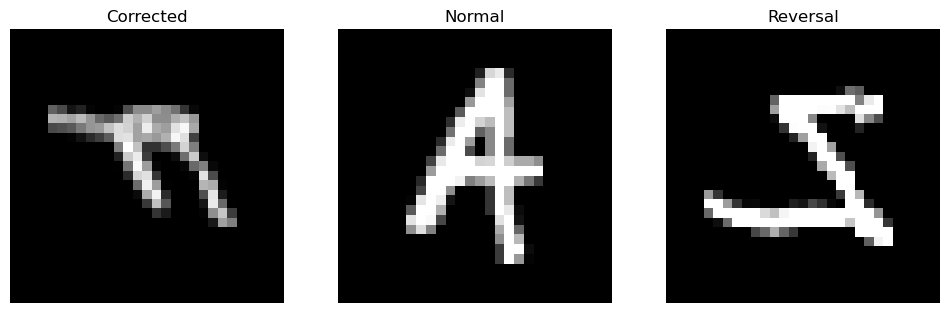

In [9]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"

classes = ["Corrected", "Normal", "Reversal"]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)
    
    # Get first image
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [1]:
import os
from PIL import Image

train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"

classes = ["Corrected", "Normal", "Reversal"]

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    print(class_name)
    print("File:", image_name)
    print("Size:", image.size)
    print("Mode:", image.mode)
    print("Format:", image.format)
    print()
    

Corrected
File: 4_1.png
Size: (29, 29)
Mode: L
Format: PNG

Normal
File: A-0.png
Size: (28, 28)
Mode: L
Format: PNG

Reversal
File: 1_1.png
Size: (29, 29)
Mode: L
Format: PNG



In [7]:
import os
from PIL import Image

train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"

for class_name in ["Corrected", "Normal", "Reversal"]:
    class_path = os.path.join(train_path, class_name)
    
    file_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, file_name)
    
    image = Image.open(image_path)
    
    print(class_name, "->", image.size, image.mode, image.format)

Corrected -> (29, 29) L PNG
Normal -> (28, 28) L PNG
Reversal -> (29, 29) L PNG


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
import tensorflow as tf

train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"
test_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale",
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

Found 151649 files belonging to 3 classes.
Found 56723 files belonging to 3 classes.


In [5]:
print("Class names:", train_dataset.class_names)

Class names: ['Corrected', 'Normal', 'Reversal']


In [6]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 64, 64, 1)
Label shape: (32,)


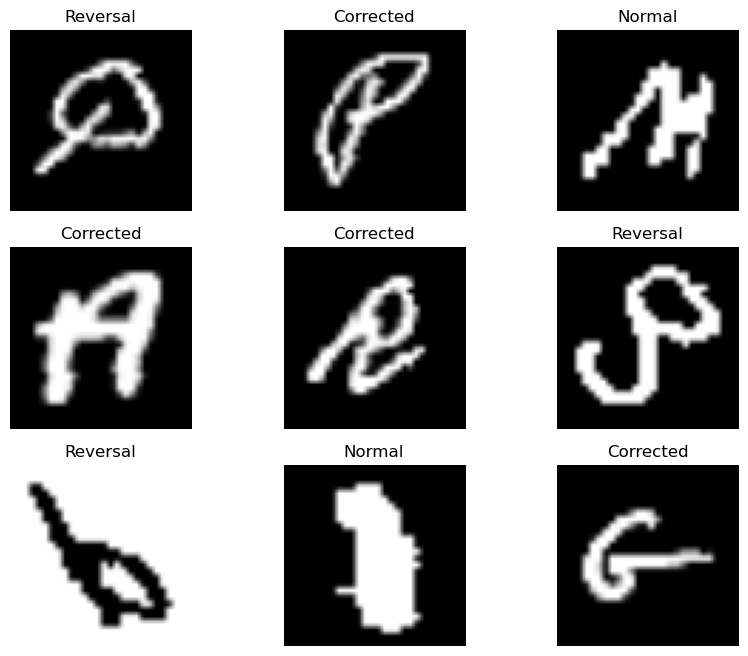

In [7]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

    plt.show()

In [13]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [14]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 0.003921569


In [15]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05)
])

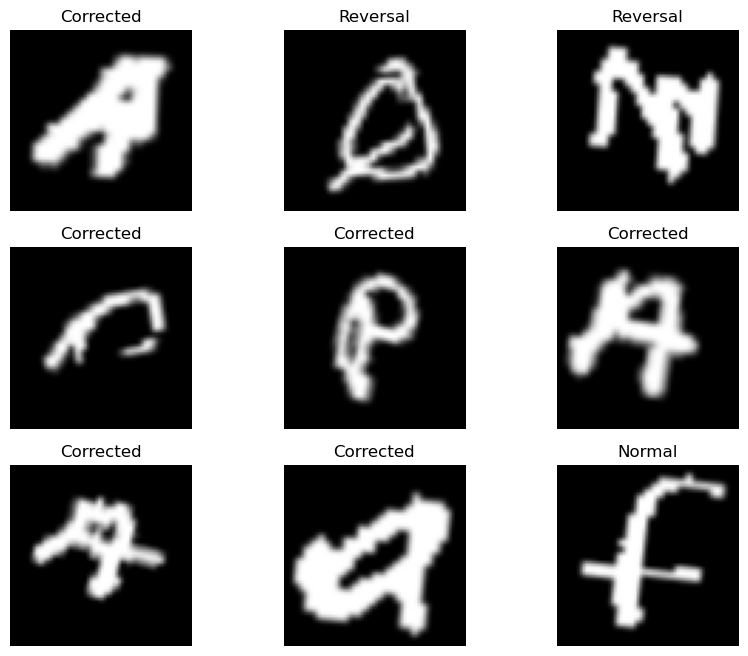

In [18]:
import matplotlib.pyplot as plt
class_names = ['Corrected', 'Normal', 'Reversal']


for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images)

    plt.figure(figsize=(10, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

    plt.show()

In [19]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    # Input
    layers.Input(shape=(64, 64, 1)),
    
    # Data augmentation
    data_augmentation,
    
    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Convert feature maps into a vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    # Output: 3 classes
    layers.Dense(3, activation="softmax")
])

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,011 (2.61 MB)

 Trainable params: 683,011 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    
    ModelCheckpoint(
        "best_dyslexia_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [1]:
import tensorflow as tf

train_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Train"
test_path = "../dataset/extracted/Dataset Dyslexia_Password WanAsy321/Gambo/Test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.10,
    subset="training",
    seed=123,
    image_size=(64, 64),
    batch_size=64,
    color_mode="grayscale",
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.10,
    subset="validation",
    seed=123,
    image_size=(64, 64),
    batch_size=64,
    color_mode="grayscale",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(64, 64),
    batch_size=64,
    color_mode="grayscale",
    shuffle=False
)

Found 151649 files belonging to 3 classes.
Using 136485 files for training.
Found 151649 files belonging to 3 classes.
Using 15164 files for validation.
Found 56723 files belonging to 3 classes.


In [2]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = train_dataset.map(
    normalize,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    normalize,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    normalize,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [3]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [4]:
print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Train batches: 2133
Validation batches: 237
Test batches: 887


In [5]:
class_weights = {
    0: 0.7714,   # Corrected
    1: 1.2851,   # Normal
    2: 1.0806    # Reversal
}

print(class_weights)

{0: 0.7714, 1: 1.2851, 2: 1.0806}


In [9]:
class_names = ["Corrected", "Normal", "Reversal"]


In [12]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05)
])

In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,011 (2.61 MB)

 Trainable params: 683,011 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1,
    class_weight=class_weights
)

In [1]:
import os
import tensorflow as tf

# Main dataset location
DATASET_PATH = r"C:\Users\dprin\Dyslexia_Project\dataset\extracted\Dataset Dyslexia_Password WanAsy321\Gambo"

# Train and Test folders
TRAIN_PATH = os.path.join(DATASET_PATH, "Train")
TEST_PATH = os.path.join(DATASET_PATH, "Test")

print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists:", os.path.exists(TEST_PATH))

Train path: C:\Users\dprin\Dyslexia_Project\dataset\extracted\Dataset Dyslexia_Password WanAsy321\Gambo\Train
Test path: C:\Users\dprin\Dyslexia_Project\dataset\extracted\Dataset Dyslexia_Password WanAsy321\Gambo\Test
Train exists: False
Test exists: False
